## Adjusting Data

In [52]:
import re
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

df = pd.read_csv("Meteorite_Landings.csv")
df = df.dropna()

# 1 = stony, 2 = iron, 3 = stony-iron
def match_class(type_str):
    if "Lodranite" in type_str or "lodranite" in type_str:
        return 3
    if "Achondrite" in type_str:
        return 1
    if "Angrite" in type_str:
        return 1
    if "Acapulcoite" in type_str:
        return 1
    if "Brachinite" in type_str:
        return 1
    if "Lunar" in type_str:
        return 1
    if "Martian" in type_str:
        return 1
    if "Chondrite" in type_str:
        return 1
    if "Aubrite" in type_str:
        return 1
    if "Eucrite" in type_str:
        return 1
    if "Iron" in type_str or "iron" in type_str:
        return 2
    if "Stone" in type_str:
        return 1
    if "OC" in type_str:
        return 1
    if "Ureilite" in type_str:
        return 1
    if "Winonaite" in type_str:
        return 1
    if "Pallasite" in type_str:
        return 3
    if "Mesosiderite" in type_str:
        return 3
    if "Howardite" in type_str:
        return 1
    if "Diogenite" in type_str:
        return 1
    if "LL" in type_str:
        return 1
    r_class = re.compile("R[^A-Za-z]")
    if r_class.match(type_str):
        return 1
    l_class = re.compile("L[^A-Za-z]")
    if l_class.match(type_str):
        return 1
    h_class = re.compile("H[^A-Za-z]")
    if h_class.match(type_str):
        return 1
    e_class = re.compile("E[^A-Za-z]")
    if e_class.match(type_str):
        return 1
    el_class = re.compile("EL[^A-Za-z]")
    if el_class.match(type_str):
        return 1
    c_num_class = re.compile("C\\d")
    if c_num_class.match(type_str):
        return 1
    cx_class = re.compile("C[A-Z]")
    if cx_class.match(type_str):
        return 1
    eh_class = re.compile("EH[^A-Za-z]")
    if eh_class.match(type_str):
        return 1
    if "K" == type_str or "K3" == type_str:
        return 1
    if (type_str == "C" or type_str == "E" or
        type_str == "EH" or type_str == "H" or
        type_str == "L" or type_str == "R"):
        return 1
    if type_str == "Enst achon-ung":
        return 1
    if type_str == "Fusion crust":
        return 1

type_list = []
for index in range(len(df["recclass"])):
    type_str = df["recclass"].iloc[index]
    type = match_class(type_str)
    if type is not None:
        type_list.append(type)

df['Class Number'] = type_list

## Relative feature importance to determining latitude

Text(0.5, 1.0, 'Feature Relative Importance to Determining Longitude')

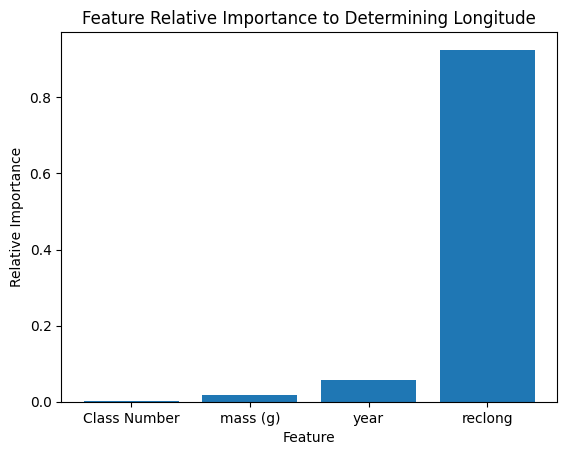

In [53]:
from sklearn.ensemble import RandomForestRegressor

X = df[["Class Number", "mass (g)", "year", "reclong"]]
y = df["reclat"]
rf = RandomForestRegressor().fit(X, y)
plt.bar(X.keys(), rf.feature_importances_)
plt.xlabel('Feature')
plt.ylabel('Relative Importance')
plt.title("Feature Relative Importance to Determining Longitude")

## Relative feature importance to determining longitude


Text(0.5, 1.0, 'Feature Relative Importance to Determining Longitude')

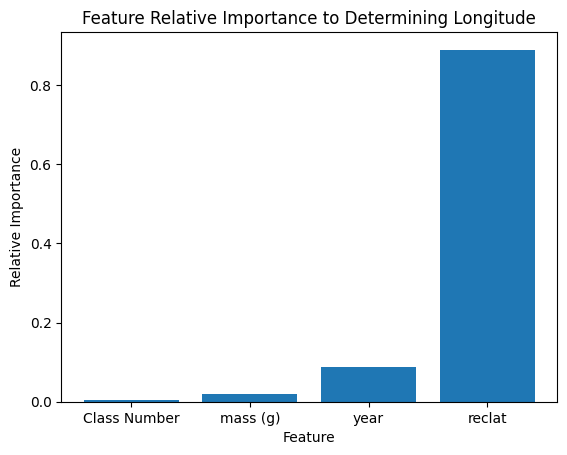

In [54]:
from sklearn.ensemble import RandomForestRegressor

X = df[["Class Number", "mass (g)", "year", "reclat"]]
y = df["reclong"]
rf = RandomForestRegressor().fit(X, y)
plt.bar(X.keys(), rf.feature_importances_)
plt.xlabel('Feature')
plt.ylabel('Relative Importance')
plt.title("Feature Relative Importance to Determining Longitude")

## Gradient boosting to predict meteorite location

## Gaussian mixture Bayesian Information Criterion

/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
/Users/quinnhelfand/Documents/GitHub/School/ISCI-396/.venv/lib/python3.13/site-packages/sklearn/mixture/_base.py:275: Conver

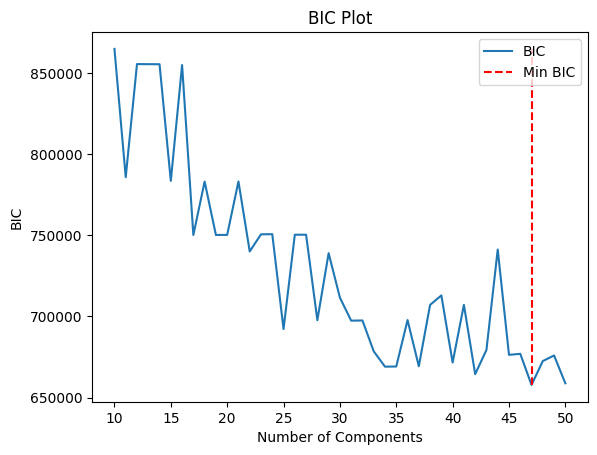

In [58]:
from sklearn.mixture import GaussianMixture
import numpy as np

bic = []
min_iter = 10
max_iter = 51
for n_clusters in range(min_iter, max_iter):
    gmm = GaussianMixture(n_components=n_clusters).fit(X)
    bic.append(gmm.bic(X))
plt.plot(range(min_iter, max_iter), bic, label='BIC')
plt.title('BIC Plot')
plt.xlabel('Number of Components')
plt.ylabel('BIC')
plt.vlines(np.argmin(bic) + min_iter, min(bic), max(bic), ls='--', color='red', label = 'Min BIC')
plt.legend()
plt.show()